In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import mpl_interactions as pli
import tigre

import numpy as np
import matplotlib.pyplot as plt

from skimage.restoration import inpaint
from skimage.morphology import binary_dilation

# Load the mat files and extract the data
import scipy.io
import os

In [3]:


# Specify the directory where the mat files are located
directory = '/media/jericho/T7/Matt_Clinical_MetalArtifacts/OneDrive_2024-07-15/HeadNeck Dental Implants'

# Get the list of all the mat files in the directory
files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.mat')]
files.sort()

# Load the mat files into a pandas dataframe
data = []
for file in files:
    data.append(scipy.io.loadmat(file))


In [4]:

# Extract the data from the mat files into a pandas dataframe
# dict_keys(['__header__', '__version__', '__globals__', 'L', 'metadata'])
data_all = {}
for i in range(len(data)):
    print(files[i])
    f_name = files[i].split('/')[-1]
    data_all[f_name] = {}
    data_all[f_name]['projections'] = data[i]['Y']
    data_all[f_name]['metadata'] = data[i]['geom']


/media/jericho/T7/Matt_Clinical_MetalArtifacts/OneDrive_2024-07-15/HeadNeck Dental Implants/HN_Dental_Implants_BottomLayer.mat
/media/jericho/T7/Matt_Clinical_MetalArtifacts/OneDrive_2024-07-15/HeadNeck Dental Implants/HN_Dental_Implants_TopLayer.mat


## Load matt's recon, (optional)

In [5]:
recon_matt = scipy.io.loadmat('/home/jericho/Downloads/firefox-downloads/RMRRecon.mat')

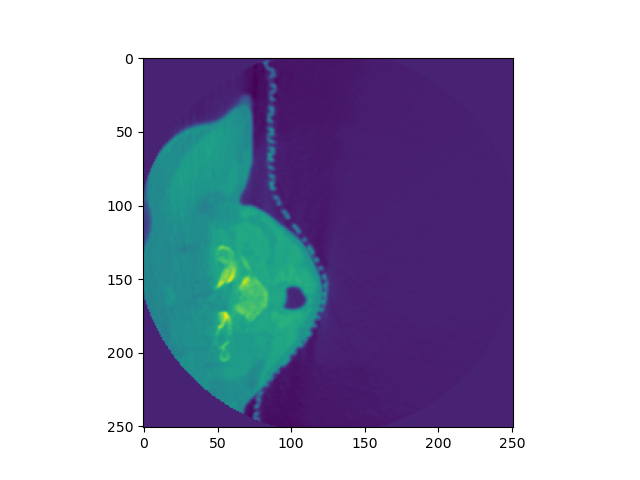

In [7]:
plt.figure()
pli.hyperslicer(recon_matt['data'].T)

## Import the layers

In [5]:
first_layer_dental_inplants_proj = -np.log(data_all['HN_Dental_Implants_TopLayer.mat']['projections'])[:].T[:,:,:]
secon_layer_dental_inplants_proj = -np.log(data_all['HN_Dental_Implants_BottomLayer.mat']['projections']).T[:,:,:]

first_layer_dental_inplants_header = data_all['HN_Dental_Implants_TopLayer.mat']['metadata']
secon_layer_dental_inplants_header = data_all['HN_Dental_Implants_BottomLayer.mat']['metadata']
# secon_layer_dental_inplants_proj = data_all['2024_01_20 CIRS801PF Pelvis BiLat_Al kV-CBCT DLI L2 140kVp 25mAs.mat']['projections']
# secon_layer_bilat_header = data_all['2024_01_20 CIRS801PF Pelvis BiLat_Al kV-CBCT DLI L2 140kVp 25mAs.mat']['metadata']

In [6]:
def inpaint_images_spine(images0,images1):
    results = []
    images2 = images0.copy()
    images3 = images1.copy()
    
    for image_high, image_low in zip(images2, images3):

        ratio0 = image_high/(image_low)

        mask = np.zeros_like(image_high)
        mask[x_ind:,125:145 ] = ratio0[x_ind:,125:145 ] > 1.05
        image_high[mask.astype(bool)] = np.NaN
        expanded_mask = binary_dilation(mask)

        expanded_mask = binary_dilation(expanded_mask)

        image_high[expanded_mask] = np.NaN
        # Inpaint image
        mask =  np.isnan(image_high)
        image_result = inpaint.inpaint_biharmonic(image_high, mask)
        results.append(image_result)
        # results.append(image_high)
    return results

x_ind = 100

# images_LI_second = inpaint_images_spine(first_layer_dental_inplants_proj.T[:],first_layer_dental_inplants_proj_nm[:])

In [7]:
# plt.figure()
ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
m1 = first_layer_dental_inplants_proj > 6.8
# ratio[first_layer_dental_inplants_proj < 5] = 0
m0 = ratio > 1.01
m2 = ratio > 1.03
m3 = ratio > 1.05
m4 = ratio > 1.07

m5 = m1.astype(int) + m2 + m3 + m4 + m0
m6 = m5 > 1

m6 = ratio/(first_layer_dental_inplants_proj)
m7 = m6 < 0.15
# m7 = m6 > np.nanpercentile(m6, 99)
# aval = first_layer_dental_inplants_proj - 
m8 = m1.astype(int) + m7 + m2
m8[first_layer_dental_inplants_proj < 5] = 0


/tmp/ipykernel_6667/2646454687.py:2: RuntimeWarning: divide by zero encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/2646454687.py:2: RuntimeWarning: invalid value encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/2646454687.py:13: RuntimeWarning: invalid value encountered in divide
  m6 = ratio/(first_layer_dental_inplants_proj)


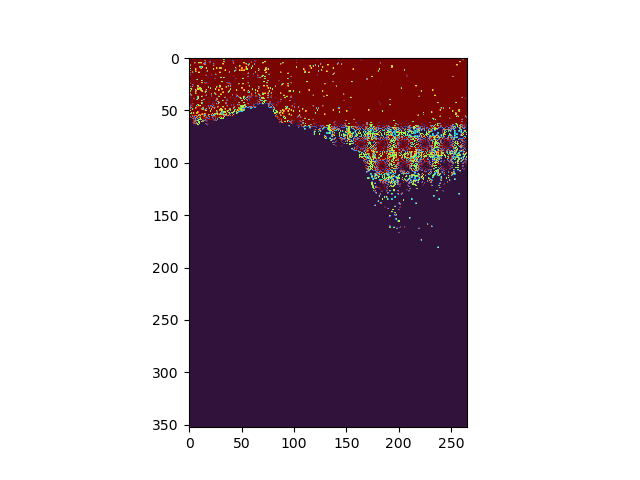

In [8]:
plt.figure()
pli.hyperslicer(np.isnan(ratio),cmap='turbo')

/tmp/ipykernel_6667/3607715909.py:5: RuntimeWarning: divide by zero encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/3607715909.py:5: RuntimeWarning: invalid value encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]


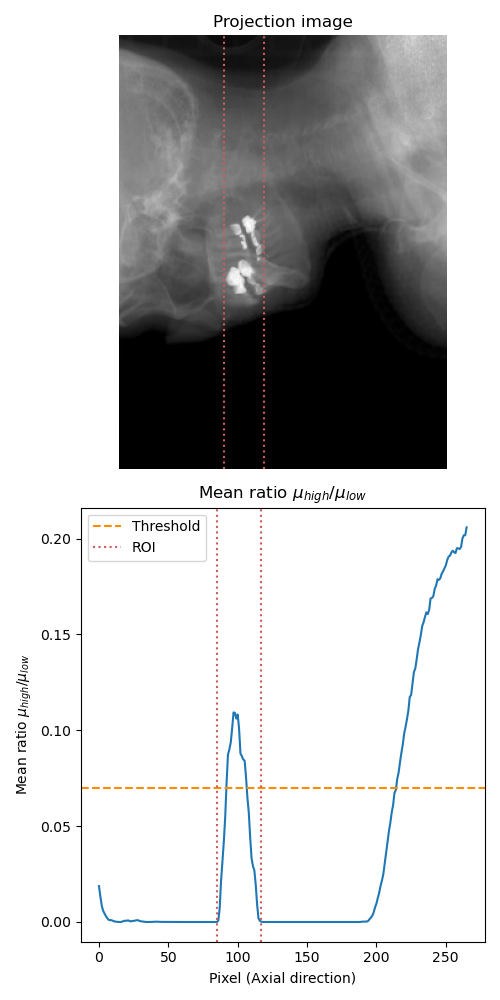

In [9]:
xlow, xhigh = 85, 117

plt.figure(figsize=(5,10))
plt.subplot(211)
ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
plt.imshow(first_layer_dental_inplants_proj[363],cmap='gray')
plt.title('Projection image')
plt.axvline(x=xlow, color='indianred', linestyle=':')
plt.axvline(x=xhigh, color='indianred', linestyle=':')
ratio[np.isinf(ratio)] = 0
ratio[np.isneginf(ratio)] = 0
ratio[np.isnan(ratio)] = 0
ratio[first_layer_dental_inplants_proj<5] = 0
# ratio[ratio > 1.07] = 0
# ratio[ratio < 1.01] = 0
plt.axis('off')
plt.subplot(212)
plt.plot(np.nanmean(ratio, axis=(0,1)))
plt.xlabel('Pixel (Axial direction)')
plt.ylabel('Mean ratio $\mu_{high}/\mu_{low}$')
plt.title('Mean ratio $\mu_{high}/\mu_{low}$')
# draw a red line horizontally at y = 0.7
plt.axhline(y=0.07, color='darkorange', linestyle='--',label='Threshold')
# draw horizontal line at x=131 and x=139
plt.axvline(x=xlow, color='indianred', linestyle=':')
plt.axvline(x=xhigh, color='indianred', linestyle=':',label='ROI')
plt.legend()
plt.tight_layout()


/tmp/ipykernel_6667/3078800852.py:4: RuntimeWarning: divide by zero encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/3078800852.py:4: RuntimeWarning: invalid value encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/3078800852.py:19: RuntimeWarning: invalid value encountered in divide
  ratio_roi = val_roi/val_adj
/tmp/ipykernel_6667/3078800852.py:35: RuntimeWarning: divide by zero encountered in divide
  ratio_roi = val_roi/val_adj
/tmp/ipykernel_6667/3078800852.py:35: RuntimeWarning: invalid value encountered in divide
  ratio_roi = val_roi/val_adj


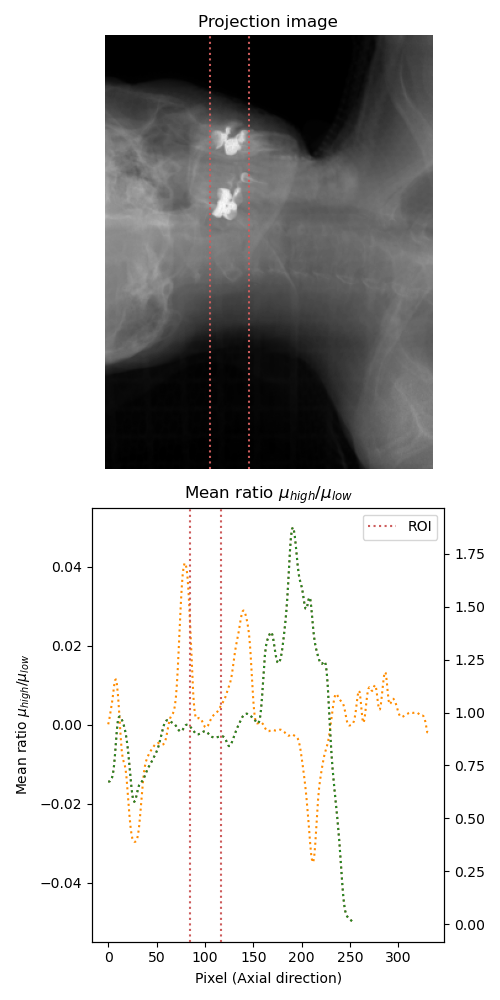

In [13]:
from scipy.ndimage import gaussian_filter

x_ind = 10
ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
plt.figure(figsize=(5,10))
plt.subplot(211)
plt.imshow(first_layer_dental_inplants_proj[138],cmap='gray')
plt.title('Projection image')
plt.axvline(x=xlow, color='indianred', linestyle=':')
plt.axvline(x=xhigh, color='indianred', linestyle=':')
ratio[np.isinf(ratio)] = 0
ratio[first_layer_dental_inplants_proj<4] = 0
ratio[ratio > 1.07] = 0
ratio[ratio < 0.8] = 0
plt.axis('off')
plt.subplot(212)
val_adj = np.nanmean(ratio[[200,300,400],x_ind:,xlow-20:xlow], axis=(2)).T
val_roi = np.nanmean(ratio[[200,300,400],x_ind:,xlow:xhigh], axis=(2)).T
ratio_roi = val_roi/val_adj
colors = ['darkorange', 'indianred', 'forestgreen', 'steelblue']
# gaussian smooth the ratio
for i, ratio in enumerate(ratio_roi.T):
    ratio_roi[:,i] = gaussian_filter(ratio, sigma=2)
# ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# colors = ['darkorange', 'indianred', 'forestgreen', 'steelblue']
for i, ratio in enumerate(ratio_roi.T):
    plt.plot(ratio,'--', color=colors[i])
plt.xlabel('Pixel (Axial direction)')
plt.ylabel('Mean ratio $\mu_{high}/\mu_{low}$')
plt.title('Mean ratio $\mu_{high}/\mu_{low}$')
# Add an axis on the right side of the plot
plt.twinx()
val_adj = np.nanmean(first_layer_dental_inplants_proj[[200,400,400],x_ind:,xlow-20:xlow], axis=(2)).T
val_roi = np.nanmean(first_layer_dental_inplants_proj[[200,400,400],x_ind:,xlow:xhigh], axis=(2)).T
ratio_roi = val_roi/val_adj
for i, ratio in enumerate(ratio_roi.T):
    ratio_roi[:,i] = gaussian_filter(ratio, sigma=2)
for i, ratio in enumerate(ratio_roi.T):
    plt.plot(ratio,':', color=colors[i])

# draw a red line horizontally at y = 0.7
# plt.axhline(y=0.07, color='darkorange', linestyle='--',label='Threshold')
# draw horizontal line at x=131 and x=139
plt.axvline(x=xlow, color='indianred', linestyle=':')
plt.axvline(x=xhigh, color='indianred', linestyle=':',label='ROI')
plt.legend()
plt.tight_layout()

/tmp/ipykernel_6667/1260439941.py:8: RuntimeWarning: divide by zero encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/1260439941.py:8: RuntimeWarning: invalid value encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/1260439941.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio2 = first_layer_dental_inplants_proj[slice_ind]/(secon_layer_dental_inplants_proj[slice_ind])
/tmp/ipykernel_6667/1260439941.py:13: RuntimeWarning: invalid value encountered in divide
  ratio2 = first_layer_dental_inplants_proj[slice_ind]/(secon_layer_dental_inplants_proj[slice_ind])
/tmp/ipykernel_6667/1260439941.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


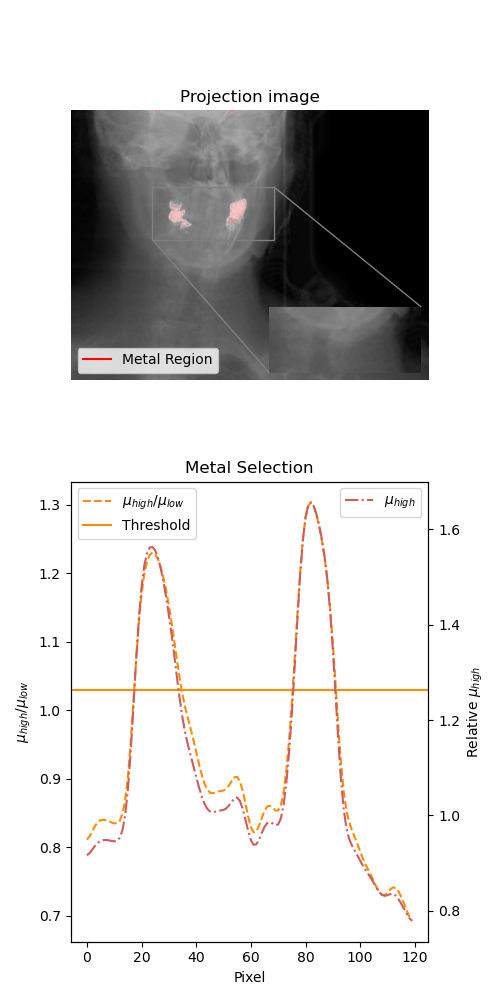

In [14]:
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes

x_ind = 240
slice_ind = 253
ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
plt.figure(figsize=(5,10))
plt.subplot(211)
plt.imshow(first_layer_dental_inplants_proj[363].T,cmap='gray')
# gt = 2 > (first_layer_dental_inplants_proj[slice_ind].T/first_layer_bilat_proj_nm.T[slice_ind].T).astype(np.float32) > 1.05
ratio2 = first_layer_dental_inplants_proj[slice_ind]/(secon_layer_dental_inplants_proj[slice_ind])
ratio2[first_layer_dental_inplants_proj[slice_ind] < 5] = 0
# plt.axis('off')
gt = (ratio2 > 1.05).astype(np.float32)
plt.imshow(first_layer_dental_inplants_proj[slice_ind].T,cmap='gray',alpha=1)
gt[gt==0] = np.NaN
plt.imshow(gt.T,cmap='flag',alpha=0.2,label='Metal')
plt.title('Projection image')
# plt.axhline(y=131, color='cornflowerblue', linestyle=':')
# plt.axhline(y=139, color='cornflowerblue', linestyle=':',label='ROI')
# plt.axvline(x=307, color='forestgreen', linestyle=':')
# plt.axvline(x=256, color='forestgreen', linestyle=':')
# plt.axvline(x=332, color='forestgreen', linestyle=':',label='Metal Boundaries')
plt.plot(1,1,'r-',label='Metal Region')
ratio[np.isinf(ratio)] = 0
ratio[first_layer_dental_inplants_proj<4] = 0
ratio[ratio > 1.07] = 0
ratio[ratio < 0.8] = 0
plt.axis('off')
plt.legend(loc=3)
# Make a zoom inset axis for the ROI region
# Inset axes
ax = plt.gca()


axins = zoomed_inset_axes(ax, zoom=1.25, loc=4)
axins.imshow(np.flipud(first_layer_dental_inplants_proj[slice_ind].T),cmap='gray')
axins.imshow(np.flipud(gt.T),cmap='flag',alpha=0.2,label='Metal')

plt.axis('off')
# Specify the limits
x1, x2, y1, y2 = 80, 200, xlow-10, xhigh + 10 # specify the limits

axins.set_xlim(x1, x2)  # apply the x-limits
axins.set_ylim(y1, y2)  # apply the y-limits

# Indicate zoom location

mark_inset(ax, axins, loc1=1, loc2=3, fc="none", ec="0.5")

plt.subplot(212)
val_adj = np.nanmean(first_layer_dental_inplants_proj[slice_ind,80:200,xlow-20:xlow], axis=(1)).T
val_roi = np.nanmean(secon_layer_dental_inplants_proj[slice_ind,80:200,xlow:xhigh], axis=(1)).T
ratio_roi = val_roi/val_adj
colors = ['darkorange', 'indianred', 'forestgreen', 'steelblue']
# gaussian smooth the ratio
# for i, ratio in enumerate(ratio_roi.T):
ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# colors = ['darkorange', 'indianred', 'forestgreen', 'steelblue']
# for i, ratio in enumerate(ratio_roi.T):
plt.plot(ratio_roi.T,'--', color='darkorange',label='$\mu_{high}/\mu_{low}$')
plt.axhline(y=1.03, color='darkorange', linestyle='-',label='Threshold')
plt.xlabel('Pixel')
plt.ylabel('$\mu_{high}/\mu_{low}$')
plt.title('Metal Selection')
plt.legend()
# Add an axis on the right side of the plot
plt.twinx()
val_adj = np.nanmean(first_layer_dental_inplants_proj[slice_ind,80:200,xlow-20:xlow], axis=(1)).T
val_roi = np.nanmean(first_layer_dental_inplants_proj[slice_ind,80:200,xlow:xhigh], axis=(1)).T
ratio_roi = val_roi/val_adj

ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# for i, ratio in enumerate(ratio_roi.T):
plt.plot(ratio_roi,'-.', color='indianred',label='$\mu_{high}$')
plt.ylabel('Relative $\mu_{high}$')
# plot the groundtruth as a red line
# gt_line = np.nansum(gt.T[129:142,x_ind:].astype(np.float32),axis=0)
# gt_line[gt_line==0] = np.NaN
# gt_line[gt_line > 0] = 1
# plt.plot(gt_line,'b-',label='Ground Truth')
# val_adj = np.nanmean(first_layer_dental_inplants_proj[slice_ind,x_ind:,111:129], axis=(1)).T
# val_roi = np.nanmean(first_layer_bilat_proj.T[slice_ind,x_ind:,131:139], axis=(1)).T
# ratio_roi = val_roi/val_adj

# ratio_roi = gaussian_filter(ratio_roi, sigma=2)

# plt.plot(ratio,':', color=colors[i])

# draw a red line horizontally at y = 0.7
# plt.axhline(y=0.07, color='darkorange', linestyle='--',label='Threshold')
# draw horizontal line at x=131 and x=139
# plt.axvline(x=18, color='forestgreen', linestyle=':')
# plt.axvline(x=68, color='forestgreen', linestyle=':',label='Metal Boundaries')
# plt.axvline(x=93, color='indianred', linestyle=':')
# Convert the axvlines to regions of forestgreen between them
# plt.fill_betweenx([0.98,1.4], 18, 68, color='forestgreen', alpha=0.2,label='Metal Region')
# plt.fill_betweenx([0.98,1.4], 93, 112, color='forestgreen', alpha=0.2)
# plt.axhline(y=1.1, color='indianred', linestyle='-',label='Threshold')
plt.legend()
plt.tight_layout()

/tmp/ipykernel_6667/2832999002.py:8: RuntimeWarning: divide by zero encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/2832999002.py:8: RuntimeWarning: invalid value encountered in divide
  ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
/tmp/ipykernel_6667/2832999002.py:13: RuntimeWarning: divide by zero encountered in divide
  ratio2 = first_layer_dental_inplants_proj[slice_ind]/(secon_layer_dental_inplants_proj[slice_ind])
/tmp/ipykernel_6667/2832999002.py:13: RuntimeWarning: invalid value encountered in divide
  ratio2 = first_layer_dental_inplants_proj[slice_ind]/(secon_layer_dental_inplants_proj[slice_ind])
/tmp/ipykernel_6667/2832999002.py:58: RuntimeWarning: invalid value encountered in divide
  ratio_roi = val_roi/val_adj
/tmp/ipykernel_6667/2832999002.py:76: RuntimeWarning: divide by zero encountered in divide
  ratio_roi = val_roi/val_adj
/tmp/ipykernel_6667/2832999002.py

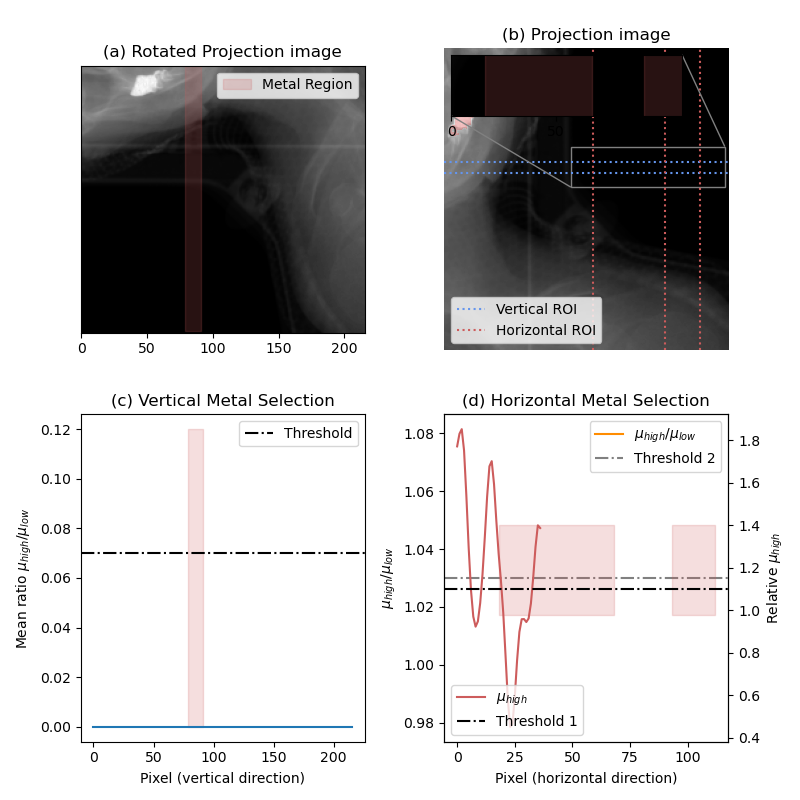

In [15]:
from scipy.ndimage import gaussian_filter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes

x_ind = 240
slice_ind = 253
ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
plt.figure(figsize=(8,8))
plt.subplot(222)
# plt.imshow(first_layer_dental_inplants_proj[slice_ind].T,cmap='gray')
# gt = 2 > (first_layer_dental_inplants_proj[slice_ind].T/first_layer_bilat_proj_nm.T[slice_ind].T).astype(np.float32) > 1.05
ratio2 = first_layer_dental_inplants_proj[slice_ind]/(secon_layer_dental_inplants_proj[slice_ind])
ratio2[first_layer_dental_inplants_proj[slice_ind] < 5] = 0
# plt.axis('off')
gt = (ratio2 > 1.05).astype(np.float32)
plt.imshow(first_layer_dental_inplants_proj[slice_ind].T[50:,150:],cmap='gray',alpha=1)
gt[gt==0] = np.NaN
plt.imshow(gt.T[50:,150:],cmap='flag',alpha=0.2,label='Ground truth')
plt.title('(b) Projection image')
plt.axhline(y=131-50, color='cornflowerblue', linestyle=':')
plt.axhline(y=139-50, color='cornflowerblue', linestyle=':',label='Vertical ROI')
plt.axvline(x=307-150, color='indianred', linestyle=':')
plt.axvline(x=256-150, color='indianred', linestyle=':')
plt.axvline(x=332-150, color='indianred', linestyle=':',label='Horizontal ROI')
# Turn these into a fill between

# plt.plot(1,1,'r-',label='Ground Truth')
ratio[np.isinf(ratio)] = 0
ratio[first_layer_dental_inplants_proj<4] = 0
ratio[ratio > 1.07] = 0
ratio[ratio < 0.8] = 0
plt.axis('off')
plt.legend(loc=3)
# Make a zoom inset axis for the ROI region
# Inset axes
ax = plt.gca()


axins = zoomed_inset_axes(ax, zoom=1.5, loc=2)
axins.imshow(first_layer_dental_inplants_proj[slice_ind].T[50:,150:],cmap='gray')
plt.fill_betweenx([0, first_layer_dental_inplants_proj[slice_ind].T[50:,150:].shape[0]-2], 256-150, 307-150, color='indianred', alpha=0.2)#,label='Metal Region')
plt.fill_betweenx([0, first_layer_dental_inplants_proj[slice_ind].T[50:,150:].shape[0]-2], 332-150, 355-150, color='indianred', alpha=0.2)
plt.yticks([])
plt.xticks([90,140,190],labels=[0,50,100])
# Specify the limits
x1, x2, y1, y2 = x_ind-150, 350-150,120-50, 149 -50# specify the limits
axins.set_xlim(x1, x2)  # apply the x-limits
axins.set_ylim(y1, y2)  # apply the y-limits

# Indicate zoom location

mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="0.5")

plt.subplot(224)
val_adj = np.nanmean(ratio[slice_ind,x_ind:,111:129], axis=(1)).T
val_roi = np.nanmean(ratio[slice_ind,x_ind:,131:139], axis=(1)).T
ratio_roi = val_roi/val_adj
colors = ['darkorange', 'indianred', 'forestgreen', 'steelblue']
# gaussian smooth the ratio
# for i, ratio in enumerate(ratio_roi.T):
ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# colors = ['darkorange', 'indianred', 'forestgreen', 'steelblue']
# for i, ratio in enumerate(ratio_roi.T):
plt.plot(ratio_roi.T,'-', color=colors[0],label='$\mu_{high}/\mu_{low}$')
plt.axhline(y=1.03, color='gray', linestyle='-.',label='Threshold 2')
plt.xlabel('Pixel (horizontal direction)')
plt.ylabel('$\mu_{high}/\mu_{low}$')
plt.title('(d) Horizontal Metal Selection')
plt.legend(loc='upper right')
# Add an axis on the right side of the plot
plt.twinx()
val_adj = np.nanmean(first_layer_dental_inplants_proj[slice_ind,x_ind:,105:129], axis=(1)).T
val_roi = np.nanmean(first_layer_dental_inplants_proj[slice_ind,x_ind:,131:139], axis=(1)).T
ratio_roi = val_roi/val_adj

ratio_roi = gaussian_filter(ratio_roi, sigma=2)
# for i, ratio in enumerate(ratio_roi.T):
plt.plot(ratio_roi,'-', color='indianred',label='$\mu_{high}$')
plt.ylabel('Relative $\mu_{high}$')
plt.fill_betweenx([0.98,1.4], 18, 68, color='indianred', alpha=0.2)#,label='Metal Region')
plt.fill_betweenx([0.98,1.4], 93, 112, color='indianred', alpha=0.2)
plt.axhline(y=1.1, color='k', linestyle='-.',label='Threshold 1')
plt.legend(loc='lower left')
# plt.tight_layout()
# plt.figure(figsize=(5,10))
plt.subplot(221)
ratio = first_layer_dental_inplants_proj[:]/secon_layer_dental_inplants_proj[:]
plt.imshow(first_layer_dental_inplants_proj[slice_ind][150:,50:],cmap='gray')
plt.title('(a) Rotated Projection image')
# plt.axvline(x=131-50, color='indianred', linestyle=':')
# plt.axvline(x=139-50, color='indianred', linestyle=':',label='Metal Region')
plt.fill_betweenx([0, first_layer_dental_inplants_proj[slice_ind][150:,50:].shape[0]-2], 129-50, 141-50, color='indianred', alpha=0.2,label='Metal Region')
ratio[np.isinf(ratio)] = 0
ratio[first_layer_dental_inplants_proj<6] = 0
ratio[ratio > 1.07] = 0
ratio[ratio < 1.01] = 0

plt.yticks([])
plt.legend()
plt.subplot(223)
plt.plot(np.nanmean(ratio, axis=(0,1))[50:])
plt.xlabel('Pixel (vertical direction)')
plt.ylabel('Mean ratio $\mu_{high}/\mu_{low}$')
plt.title('(c) Vertical Metal Selection')
# draw a red line horizontally at y = 0.7
plt.axhline(y=0.07, color='k', linestyle='-.',label='Threshold')
# draw horizontal line at x=131 and x=139
# plt.axvline(x=131, color='indianred', linestyle=':')
# plt.axvline(x=139, color='indianred', linestyle=':')#,label='ROI')
# # Fill between the metal boundaries
plt.fill_betweenx([0, 0.12], 129-50, 141-50, color='indianred', alpha=0.2)#,label='Metal Region')
plt.legend(loc='upper right')
plt.tight_layout()

# plt.savefig('metal_selection.png',dpi=300)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data, color
from skimage.transform import hough_circle, hough_circle_peaks
from skimage.feature import canny
from skimage.draw import circle_perimeter, disk
from skimage.util import img_as_ubyte
from skimage.restoration import inpaint
from skimage.morphology import binary_dilation
from skimage.morphology import binary_opening, square
# import matplotlib.pyplot as plt
from scipy.ndimage import binary_fill_holes
from skimage import data, filters

def trace_replacement_spine(images0,images1,images4, xlow, xhigh, ylow, yhigh):
    results = []
    images2 = images0.copy()
    images3 = images1.copy()
    images4 = images4.copy()
    mask_gts = []
    masks = []
    
    for image_high, image_low, image_low2 in zip(images2, images3, images4):

        ratio0 = image_high/(image_low)
        ratio0[image_high < 2] = 0

        mask = np.zeros_like(image_high)
    
        image = ratio0[ylow:yhigh,xlow:xhigh]
        # image[image_high[ylow:yhigh,xlow:xhigh] < 2] = 0
        edges = filters.sobel(image)
        low = np.percentile(edges, 83)
        high = np.percentile(edges, 96)
        hyst = filters.apply_hysteresis_threshold(edges, low, high)
        # close a
        hyst = binary_fill_holes(hyst)
        # hyst = binary_closing(hyst)
        # masks.append(hyst)

        image = image_high[ylow:yhigh,xlow:xhigh]
        # image[first_layer_dental_inplants_proj[ii,50:250,xlow:xhigh] < 2] = 0
        edges = filters.sobel(image)
        low = np.percentile(edges, 83)
        high = np.percentile(edges, 96)
        hyst2 = filters.apply_hysteresis_threshold(edges, low, high)
        # close a
        hyst2 = binary_fill_holes(hyst2)
        # hyst = binary_closing(hyst)

        mask[ylow:yhigh,xlow:xhigh] = hyst2 + hyst
        # mask[image_high < 2.5] = 0
        expanded_mask = binary_fill_holes(mask)

        expanded_mask = binary_dilation(expanded_mask)
        expanded_mask = binary_dilation(expanded_mask)
        # expanded_mask = binary_dilation(expanded_mask)
        # expanded_mask = binary_dilation(expanded_mask)
        # expanded_mask[image_high < 2.5] = 0
        
        masks.append(expanded_mask)
        mask_gts.append(mask)


    masks = np.array(masks)
    # results = np.zeros_like(images2)
    # for ii in range(images2.shape[2]):
    #     mask = masks[:,:,ii].copy(order='C')
    #     image = (images2+ images3)[:,:,ii].squeeze()
    #     # print(mask.shape,image.shape)
    #     results[:,:,ii] = inpaint.inpaint_biharmonic(image, mask)

    # results2 = np.zeros_like(images2)
    # for ii in range(images2.shape[1]):
    #     mask = masks[:,ii,:].copy(order='C')
    #     image = (images2+ images3)[:,ii,:].squeeze()
    #     # print(mask.shape,image.shape)
    #     results2[:,ii,:] = inpaint.inpaint_biharmonic(image, mask)

    results3 = np.zeros_like(images2)
    for ii in range(images2.shape[0]):
        mask = masks[ii,:,:].copy(order='C')
        image = (images2+ images3)[ii,:,:].squeeze()
        # print(mask.shape,image.shape)
        results3[ii,:,:] = inpaint.inpaint_biharmonic(image, mask)
        
    
    # compute the dice score between the masks and the ground truth masks
    dice_scores = []
    # Compute the false positive and false negative rates
    false_positive = []
    false_negative = []
    # for mask, mask_gt in zip(masks, mask_gts):
    #     dice_scores.append(2*np.sum(mask*mask_gt)/(np.sum(mask) + np.sum(mask_gt)))
    #     false_positive.append(np.sum(mask*(1-mask_gt))/np.sum(mask))
    #     false_negative.append(np.sum((1-mask)*mask_gt)/np.sum(mask_gt))
    # print('Dice scores: ', np.mean(dice_scores))
    # print('False positive: ', np.mean(false_positive))
    # print('False negative: ', np.mean(false_negative))
    return 0 ,0,np.array(results3).T, masks, mask_gts #np.array(results).T, np.array(results2).T, np.array(results3).T, masks, mask_gts

images_LI_tr, images_LI_tr2, images_LI_tr3, masks_all, mask_gts = trace_replacement_spine(first_layer_dental_inplants_proj[:],
secon_layer_dental_inplants_proj,secon_layer_dental_inplants_proj, xlow=75, xhigh=125, ylow=60, yhigh=260)

/tmp/ipykernel_6667/4056940824.py:25: RuntimeWarning: divide by zero encountered in divide
  ratio1 = image_high/(image_low2)
/tmp/ipykernel_6667/4056940824.py:25: RuntimeWarning: invalid value encountered in divide
  ratio1 = image_high/(image_low2)
/tmp/ipykernel_6667/4056940824.py:27: RuntimeWarning: divide by zero encountered in divide
  ratio0 = image_high/(image_low)
/tmp/ipykernel_6667/4056940824.py:27: RuntimeWarning: invalid value encountered in divide
  ratio0 = image_high/(image_low)


/tmp/ipykernel_6667/3634718662.py:3: RuntimeWarning: divide by zero encountered in divide
  image = first_layer_dental_inplants_proj[99,50:250,xlow:xhigh]/secon_layer_dental_inplants_proj[300,50:250,xlow:xhigh]


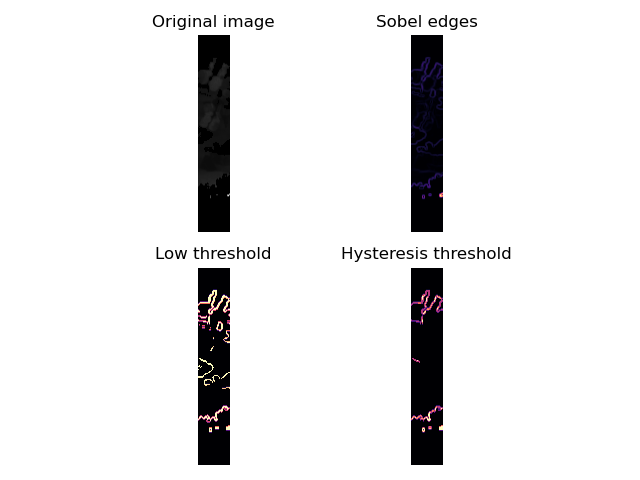

In [21]:


fig, ax = plt.subplots(nrows=2, ncols=2)

image = first_layer_dental_inplants_proj[99,50:250,xlow:xhigh]/secon_layer_dental_inplants_proj[300,50:250,xlow:xhigh]
image[first_layer_dental_inplants_proj[99,50:250,xlow:xhigh] < 3] = 0

edges = filters.sobel(image)

low = np.percentile(edges, 90)
high = np.percentile(edges, 98)

lowt = (edges > low).astype(int)
hight = (edges > high).astype(int)
hyst = filters.apply_hysteresis_threshold(edges, low, high)

ax[0, 0].imshow(image, cmap='gray')
ax[0, 0].set_title('Original image')

ax[0, 1].imshow(edges, cmap='magma')
ax[0, 1].set_title('Sobel edges')

ax[1, 0].imshow(lowt, cmap='magma')
ax[1, 0].set_title('Low threshold')

ax[1, 1].imshow(hight + hyst, cmap='magma')
ax[1, 1].set_title('Hysteresis threshold')

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()

plt.show()

In [143]:
thresholded = []
thresholded2 = []
from skimage.morphology import binary_closing, square
from scipy.ndimage import binary_fill_holes

ylow, yhigh = 60, 260
xlow, xhigh = 75, 125
for ii, image in enumerate(first_layer_dental_inplants_proj/secon_layer_dental_inplants_proj):
    
    image = image[ylow:yhigh,xlow:xhigh]
    image[first_layer_dental_inplants_proj[ii,ylow:yhigh,xlow:xhigh] < 2] = 0
    edges = filters.sobel(image)
    low = np.percentile(edges, 82)
    high = np.percentile(edges, 96)
    hyst = filters.apply_hysteresis_threshold(edges, low, high)
    # close a
    hyst = binary_fill_holes(hyst)
    # hyst = binary_closing(hyst)
    thresholded.append(hyst)

for ii, image in enumerate(first_layer_dental_inplants_proj):
    
    image = image[ylow:yhigh,xlow:xhigh]
    # image[first_layer_dental_inplants_proj[ii,50:250,xlow:xhigh] < 2] = 0
    edges = filters.sobel(image)
    low = np.percentile(edges, 82)
    high = np.percentile(edges, 96)
    hyst = filters.apply_hysteresis_threshold(edges, low, high)
    # close a
    hyst = binary_fill_holes(hyst)
    # hyst = binary_closing(hyst)
    thresholded2.append(hyst)

# thresholded3 = []
# thresholded4 = []
# for ii, image in enumerate(first_layer_dental_inplants_proj/secon_layer_dental_inplants_proj):
    
#     image = image[ylow:yhigh,xlow:xhigh]
#     image[first_layer_dental_inplants_proj[ii,ylow:yhigh,xlow:xhigh] < 2] = 0
#     edges = filters.sobel(image)
#     low = np.percentile(edges, 92)
#     high = np.percentile(edges, 96)
#     hyst = filters.apply_hysteresis_threshold(edges, low, high)
#     # close a
#     hyst = binary_fill_holes(hyst)
#     # hyst = binary_closing(hyst)
#     thresholded3.append(hyst)

# for ii, image in enumerate(first_layer_dental_inplants_proj):
    
#     image = image[ylow:yhigh,xlow:xhigh]
#     # image[first_layer_dental_inplants_proj[ii,50:250,xlow:xhigh] < 2] = 0
#     edges = filters.sobel(image)
    # low = np.percentile(edges, 92)
    # high = np.percentile(edges, 96)
    # hyst = filters.apply_hysteresis_threshold(edges, low, high)
    # # close a
    # hyst = binary_fill_holes(hyst)
    # # hyst = binary_closing(hyst)
    # thresholded4.append(hyst)

results = first_layer_dental_inplants_proj[:,ylow:yhigh,xlow:xhigh].copy()
initial_masks = (np.array(thresholded2) + thresholded).copy(order='C')
# expanded_masks = (np.array(thresholded3) + thresholded4).copy(order='C')
masks = []
for ii in range(first_layer_dental_inplants_proj.shape[0]):
    mask = initial_masks[ii]
    expanded_mask = binary_fill_holes(mask)
    # expanded_mask = binary_dilation(expanded_mask)
    # expanded_mask = binary_dilation(expanded_mask)
    # pad the mask with 10 pixels on each side
    mask = np.pad(expanded_mask, ((0,0),(10,10)), mode='constant', constant_values=0)
    image = first_layer_dental_inplants_proj[ii,ylow:yhigh,xlow-10:xhigh+10].squeeze()
    inpainted = inpaint.inpaint_biharmonic(image, mask)
    # print(mask.shape,image.shape)
    results[ii][expanded_mask] = inpainted[:,10:-10][expanded_mask]
    # results[ii][expanded_mask] = 0.9*inpainted[:,10:-10][expanded_mask]
    # results[ii][expanded_mask] += 0.1*first_layer_dental_inplants_proj[ii,ylow:yhigh,xlow:xhigh][expanded_mask]
    # results[ii] = first_layer_dental_inplants_proj[ii,ylow:yhigh,xlow:xhigh][image[:,10:-10] < 2.5] #+
                            #   0.5*results[ii][image[:,10:-10] < 4])
    masks.append(expanded_mask)


for ii, (result, mask) in enumerate(zip(results.T,np.array(masks).T)):
    # print(result.shape, mask.shape)
    image_2 = rem.remove_stripe_based_wavelet_fft(result, 5, size=50)
    results.T[ii][mask] = 1*image_2[mask]
    # results.T[ii][mask] += 0.05*first_layer_dental_inplants_proj[:,ylow:yhigh,xlow:xhigh].T[ii][mask]


# redo the same thing for the other direction
initial_masks = np.array(thresholded2 + thresholded).copy(order='C')
results2 = np.zeros_like(first_layer_dental_inplants_proj[:,ylow:yhigh,xlow:xhigh])
masks2 = []


/tmp/ipykernel_6667/3840142667.py:8: RuntimeWarning: divide by zero encountered in divide
  for ii, image in enumerate(first_layer_dental_inplants_proj/secon_layer_dental_inplants_proj):
/tmp/ipykernel_6667/3840142667.py:8: RuntimeWarning: invalid value encountered in divide
  for ii, image in enumerate(first_layer_dental_inplants_proj/secon_layer_dental_inplants_proj):


In [103]:
import algotom.io.loadersaver as losa
import algotom.prep.calculation as calc
import algotom.prep.removal as rem
import algotom.rec.reconstruction as rec


# center1 = calc.find_center_vo(results.T[20])
# center2 = calc.find_center_vo(sinogram2)
sinogram1 = rem.remove_stripe_based_wavelet_fft(results.T[20], 5, size=50)
# sinogram2 = rem.remove_all_stripe(sinogram2, snr=3.0, la_size=51, sm_size=21)

# img_rec1 = rec.dfi_reconstruction(sinogram1, center1)
# img_rec2 = rec.dfi_reconstruction(sinogram2, center2)
# losa.save_image(output_base + "/rec_sample1.tif", img_rec1)
# losa.save_image(output_base + "/rec_sample2.tif", img_rec2)

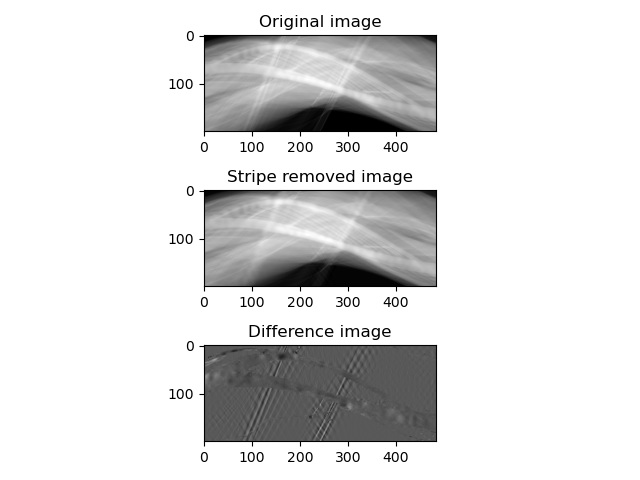

In [122]:
plt.figure()
plt.subplot(311)
plt.imshow(results.T[20],cmap='gray')
plt.title('Original image')
plt.subplot(312)
plt.imshow(sinogram1,cmap='gray')
plt.title('Stripe removed image')
plt.subplot(313)
plt.imshow(results.T[20] - sinogram1,cmap='gray')
plt.title('Difference image')
plt.tight_layout()

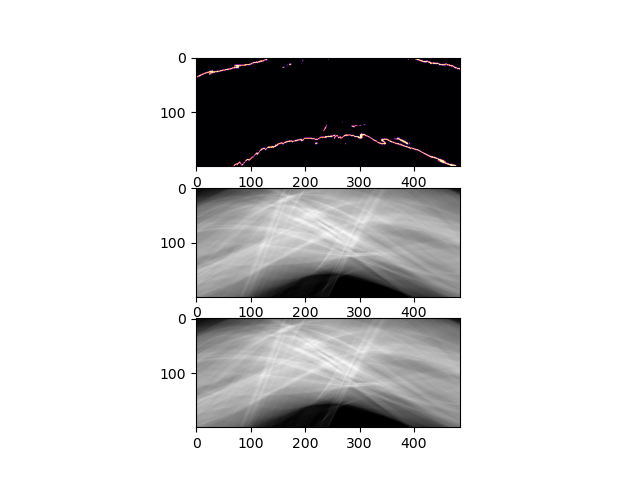

In [136]:
plt.figure(
)
plt.subplot(311)
cont = pli.hyperslicer(np.array(expanded_masks).T,cmap='magma')
plt.subplot(312)
pli.hyperslicer(first_layer_dental_inplants_proj[:, 60:260,xlow:xhigh].T,cmap='gray',controls=cont)
plt.subplot(313)
pli.hyperslicer(results.T,cmap='gray',controls=cont)

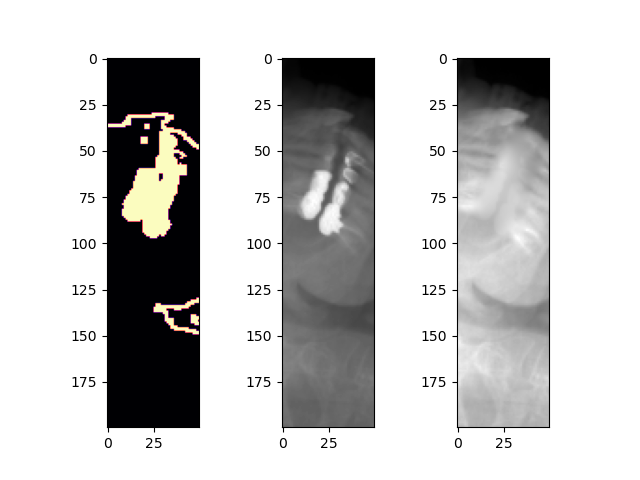

In [137]:
plt.figure()
plt.subplot(131)
cont = pli.hyperslicer(np.array(expanded_masks),cmap='magma')
plt.subplot(132)
pli.hyperslicer(first_layer_dental_inplants_proj[:, 60:260,xlow:xhigh],cmap='gray',controls=cont)
plt.subplot(133)
pli.hyperslicer(results,cmap='gray',controls=cont)

In [144]:
image_modified = first_layer_dental_inplants_proj.copy()

image_modified[:, 60:260,xlow:xhigh] = results

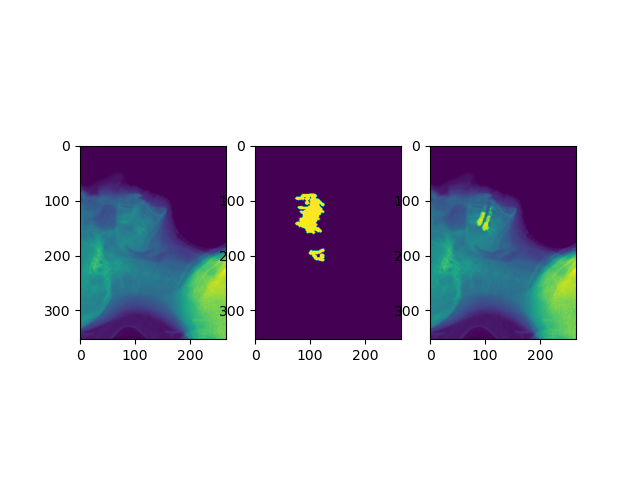

In [139]:
plt.figure()
plt.subplot(131)
cont = pli.hyperslicer(image_modified)
plt.subplot(132)
pli.hyperslicer(masks_all,controls=cont)
plt.subplot(133)
pli.hyperslicer(first_layer_dental_inplants_proj,controls=cont)


In [127]:
geo = tigre.geometry_default()

In [128]:
# dtype=[('DSD', 'O'), ('DSO', 'O'), ('nDetector', 'O'), ('dDetector', 'O'), ('sDetector', 'O'), ('nVoxel', 'O'), ('dVoxel', 'O'), ('sVoxel', 'O'), ('offOrigin', 'O'), ('offDetector', 'O')])

geo.DSD = first_layer_dental_inplants_header[0][0][0][0].squeeze() #[-1::-1]
geo.DSO = first_layer_dental_inplants_header[0][0][1][0].squeeze() #[-1::-1]
geo.nDetector = np.array([266,353]).squeeze()
geo.dDetector = first_layer_dental_inplants_header[0][0][3].squeeze()
geo.sDetector = geo.dDetector*geo.nDetector
geo.nVoxel = first_layer_dental_inplants_header[0][0][5].squeeze()[-1::-1]
geo.dVoxel = first_layer_dental_inplants_header[0][0][6].squeeze()[-1::-1]
geo.sVoxel = first_layer_dental_inplants_header[0][0][7].squeeze()[-1::-1]
geo.offOrigin = first_layer_dental_inplants_header[0][0][8].squeeze()[-1::-1]
geo.offDetector = first_layer_dental_inplants_header[0][0][9].squeeze()[-1::-1]

In [129]:
angles_matt  = scipy.io.loadmat('/media/jericho/T7/Matt_Clinical_MetalArtifacts/ProjAngles(1)/ProjAngles.mat')
angles = np.deg2rad(angles_matt['projangles'][0])

In [130]:
# angles = np.linspace(0,np.pi*1.1,485)

In [131]:
img_first = tigre.algorithms.fdk(np.fliplr(first_layer_dental_inplants_proj.transpose(0,2,1)),geo,angles,filter='hamming')#,dowang=False)

In [55]:
img_first = tigre.algorithms.mlem(np.fliplr(first_layer_dental_inplants_proj.transpose(0,2,1)),geo,angles,niter=50)#,filter='hamming')#,dowang=False)

MLEM algorithm in progress.
Estimated time until completion : 00:00:53


In [132]:

img_second = tigre.algorithms.fdk(np.fliplr(secon_layer_dental_inplants_proj.transpose(0,2,1)),geo,angles,filter='hamming')#,dowang=False
# img_second = tigre.algorithms.mlem(np.fliplr(secon_layer_dental_inplants_proj.transpose(0,2,1)),geo,angles,niter=50)#,filter='hamming')#,dowang=False
# img_LI = tigre.algorithms.fdk(np.fliplr(np.array(images_LI).transpose(0,2,1)),geo,angles)
img_gt = tigre.algorithms.fdk(np.fliplr(first_layer_dental_inplants_proj.transpose(0,2,1)),geo,angles,filter='hamming')
# img_combined = tigre.algorithms.fdk(np.array(images_LI).transpose([0,2,1]),geo,angles,dowang=True)

In [145]:
img_tr = tigre.algorithms.mlem(np.fliplr(np.array(image_modified).transpose(0,2,1)),geo,angles,niter=50)#filter='hamming')
# img_wtr = tigre.algorithms.fdk(np.array(images_LI_wtr).transpose([0,2,1]),geo,angles,dowang=True)
# img_LI_second = tigre.algorithms.fdk(np.array(images_LI_second).transpose([0,2,1]),geo,angles,dowang=True)

MLEM algorithm in progress.
Estimated time until completion : 00:00:45


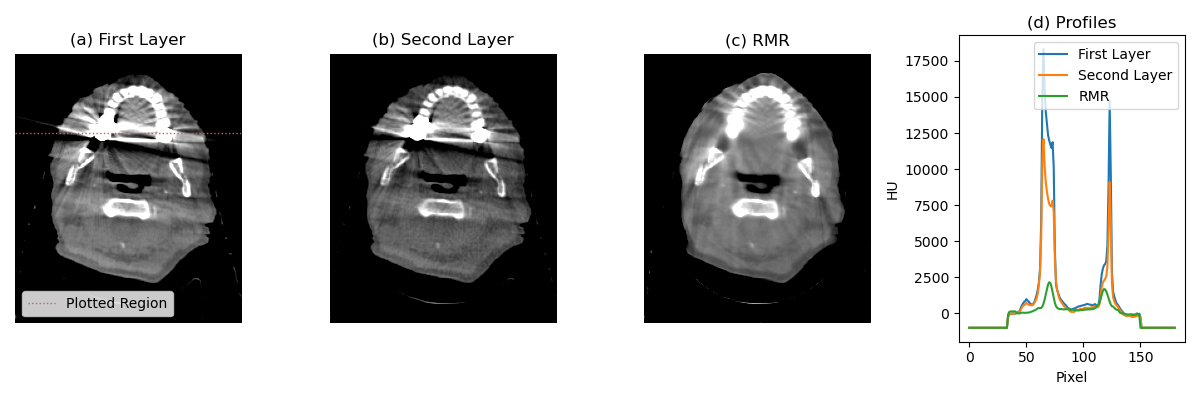

In [147]:
def mask_center(image, radius):
    # Get the center of the image
    center = np.array(image.shape) / 2

    # Create an array of the same shape as the image, filled with the squared distance from the center
    y, x = np.ogrid[:image.shape[0], :image.shape[1]]
    dist_from_center = (x - center[1])**2 + (y - center[0])**2

    # Create a mask that is True for all pixels within the specified radius of the center
    mask = dist_from_center <= radius**2

    # Use the mask to set the corresponding pixels in the original image to 0
    image[~mask] = 0

    return image


uplim = 470
lowlim= 70

# # crop the image from 512 to 416
# img = img[:,lowlim:uplim, lowlim:uplim]
# # Test the function
# image = np.ones((100, 100))
radius = 340//2
# for im in img:
#     im = mask_center(im, radius)

# img_LI0 = img_LI[:,lowlim:uplim, lowlim:uplim].copy()
# for im in img_LI0:
#     im = mask_center(im, radius)

# # img[img < 0.01] = 0
# img_LI0[img_LI0 < 0.01] = 0

# do the same for the first and second layers

img_first0 = img_first[:,lowlim-35:uplim, lowlim:uplim].copy()
for im in img_first0:
    im = mask_center(im, radius)

img_second0 = img_second[:,lowlim-35:uplim, lowlim:uplim].copy()
for im in img_second0:
    im = mask_center(im, radius)

img_gt0 = img_gt[:,lowlim-35:uplim, lowlim:uplim].copy()
for im in img_gt0:
    im = mask_center(im, radius)

img_tr0 = img_tr[:,lowlim-35:uplim, lowlim:uplim].copy()
for im in img_tr0:
    im = mask_center(im, radius)

# img_one0 = img_one[:,48:uplim, 48:uplim].copy()
# for im in img_one0:
#     im = mask_center(im, radius)

# coeff = 0

# img_first0 -= coeff*img_one0
# img_second0 -= coeff*img_one0
# img_LI0 -= coeff*img_one0
# img_gt0 -= coeff*img_one0
# img_tr0 -= coeff*img_one0

img_first0[img_first0 < 0.01] = 0
img_first0[img_first0 < 0.01] = 0
img_second0[img_second0< 0.01] = 0
img_gt0[img_gt0 < 0.01] = 0
img_tr0[img_tr0 < 0.01] = 0


# convert each of the images to HU using the water and air values
water = 0.0182
air = 0
# img_LI0 = (img_LI0 - air)/(w/ater - air)*1000 - 1000
img_first0 = (img_first0 - air)/(water - air)*1000 - 1000
img_second0 = (img_second0 - air)/(water - air)*1000    - 1000
img_gt0 = (img_gt0 - air)/(water - air)*1000 - 1000
img_tr0 = (img_tr0 - air)/(water - air)*1000 - 1000
# img_wtr0 = (img_wtr0 - air)/(water - air)*1000 - 1000
# img_LI_second0 = (img_LI_second0 - air)/(water - air)*1000 - 1000

zlow,zhigh = 400,800
im_num = 81

plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
plt.imshow(img_first0[im_num],vmin=-zlow,vmax=zhigh,cmap='gray')
plt.axhline(y=63, color='indianred', linestyle=':',label='Plotted Region',linewidth=1)
plt.legend(loc=3)
plt.title('(a) First Layer')
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(img_second0[im_num],vmin=-zlow,vmax=zhigh,cmap='gray')
plt.title('(b) Second Layer')
plt.axis('off')
# plt.subplot(3,2,3)
# plt.imshow(img_LI0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('Biharmonic Inpainting')
# plt.axis('off')
plt.subplot(144)
# plt.imshow(img_gt0[im_num],vmin=-zlow,vmax=zhigh,cmap='gray')
plt.title('(d) Profiles')
plt.plot(img_first0[im_num,63,:],label='First Layer')
plt.plot(img_second0[im_num,63,:],label='Second Layer')
plt.plot(img_tr0[im_num,63,:],label='RMR')
plt.xlabel('Pixel')
plt.ylabel('HU')
plt.legend()
# plt.axhline(y=245, color='indianred', linestyle=':',label='Plotted Region')
# plt.axis('off')
plt.subplot(143)
plt.imshow(img_tr0[im_num],vmin=-zlow,vmax=zhigh,cmap='gray')
plt.title('(c) RMR')
plt.axis('off')
# plt.subplot(3,2,6)
# plt.imshow(img_LI_second0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('Biharmonic Inpainting Second Layer')
# plt.axis('off')

plt.tight_layout()
# plt.savefig('RMR_vs_GT_clinical_removed.png',dpi=300)

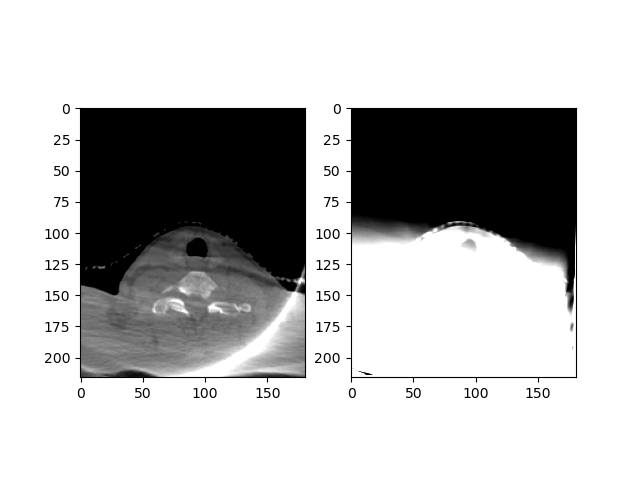

In [148]:
plt.figure()
plt.subplot(121)
cont = pli.hyperslicer(img_first0,cmap='gray',vmin=-400,vmax=1200)
# plt.figure()
# summed = (np.array(images_LI_tr2).T +np.array(images_LI_tr).T)/2
# summed[masks_all] = image_filt[masks_all]
plt.subplot(122)
pli.hyperslicer(img_tr0,cmap='gray',controls=cont,vmin=-400,vmax=1200)

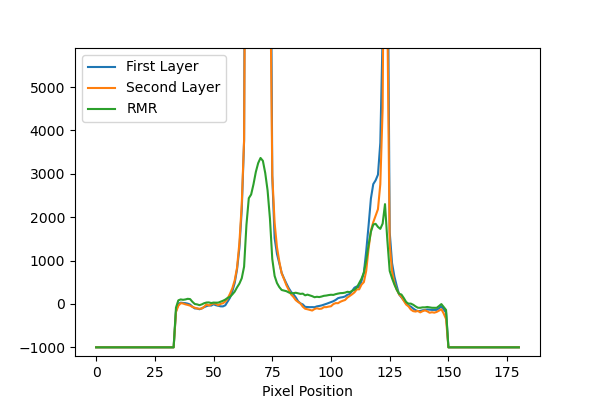

In [395]:
plt.figure(figsize=(6, 4))
# plt.title('(d) Profiles')
plt.plot(img_first0[im_num,63,:],label='First Layer')
plt.plot(img_second0[im_num,63,:],label='Second Layer')
plt.plot(img_tr0[im_num,63,:],label='RMR')
plt.ylim([-1200,5900])
plt.xlabel('Pixel Position')
# plt.ylabel('Pixel HU')
plt.legend()
plt.savefig('RMR_vs_GT_clinical_updated_profiles.png',dpi=300)

In [208]:
# Extract the line plotted region from each image
line_gt = img_gt0[im_num, 245, :]
line_first = img_first0[im_num, 245, :]
line_second = img_second0[im_num, 245, :]
line_tr = img_tr0[im_num, 245, :]

# Create a new figure for the line plots
plt.figure(figsize=(6, 4))

# Plot the line plotted region for each image
plt.plot(line_gt, label='Ground Truth')
plt.plot(line_first, label='First Layer')
plt.plot(line_second, label='Second Layer')
plt.plot(line_tr, label='RMR')

# Add a legend
plt.legend()

# Add labels and title
plt.xlabel('Pixel Position')
plt.ylabel('Pixel Value')
plt.title('Metal Artifact Region Comparison')

# Show the plot
plt.show()
# plt.savefig('RMR_vs_GT_line.png',dpi=300)

# print the rmses between the gt and the other lines 
rmse_first = np.sqrt(np.mean((line_gt - line_first)**2))
rmse_second = np.sqrt(np.mean((line_gt - line_second)**2))
rmse_tr = np.sqrt(np.mean((line_gt - line_tr)**2))

print(f'RMSE between the GT and the first layer: {rmse_first}')
print(f'RMSE between the GT and the second layer: {rmse_second}')
print(f'RMSE between the GT and the RMR: {rmse_tr}')

# do the same thing but averoaging over 5 lines axially to remove noise
line_gt = np.mean(img_gt0[im_num, 240:250, :], axis=0)
line_first = np.mean(img_first0[im_num, 240:250, :], axis=0)
line_second = np.mean(img_second0[im_num, 240:250, :], axis=0)
line_tr = np.mean(img_tr0[im_num, 240:250, :], axis=0) 

# Just print the rmse 
rmse_first = np.sqrt(np.mean((line_gt - line_first)**2))
rmse_second = np.sqrt(np.mean((line_gt - line_second)**2))
rmse_tr = np.sqrt(np.mean((line_gt - line_tr)**2))

print(f'RMSE between the GT and the first layer: {rmse_first}')
print(f'RMSE between the GT and the second layer: {rmse_second}')
print(f'RMSE between the GT and the RMR: {rmse_tr}')

IndexError: index 245 is out of bounds for axis 1 with size 216

In [188]:

plt.figure(figsize=(10,10))
# plt.subplot(1,1,1)
plt.imshow(img_first0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('First Layer')
plt.axis('off')
plt.savefig('spine_first.png',dpi=300)
# plt.subplot(3,2,2)
# plt.imshow(img_second0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('Second Layer')
# plt.axis('off')
# plt.subplot(3,2,3)
# plt.imshow(img_LI0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('Biharmonic Inpainting')
# plt.axis('off')
# plt.subplot(3,2,4)
# plt.imshow(img_gt0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('Ground Truth')
# plt.axis('off')

plt.figure(figsize=(10,10))
plt.imshow(img_tr0[62],vmin=-400,vmax=400,cmap='gray')
# plt.title('Trace Replacement')
plt.axis('off')
# plt.subplot(3,2,6)
plt.savefig('spine_replacement.png',dpi=300)

In [66]:
# plt.figure()

# for ii, alpha in enumerate([0.1,0.5,1.0,2.0]):
#     img_sub = tigre.algorithms.fdk((first_layer_bilat_proj - alpha*secon_layer_bilat_proj).transpose([2,0,1]),geo,angles,dowang=True)
#     img_sub0 = img_sub[:,48:uplim, 48:uplim].copy()
#     # for im in img_sub0:
#     #     im = mask_center(im, radius)
#     # img_sub0[img_sub0 < 0.01] = 0
#     # img_sub0 = (img_sub0 - air)/(water - air)*1000 - 1000
#     plt.subplot(2,2,ii+1)
#     plt.imshow(img_sub0[62],cmap='gray')
#     plt.title('Subtraction with alpha = ' + str(alpha))
#     plt.axis('off')

img_sub = tigre.algorithms.fdk((first_layer_bilat_proj - 2*secon_layer_bilat_proj).transpose([2,0,1]),geo,angles,dowang=True)

FDK: applying detector offset weights
-285 639 0 -38.24000000000001
TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1527.3 mm
Distance from source to origin (DSO)= 1000 mm
-----
Detector parameters
Number of pixels (nDetector) = [266 639]
Size of each pixel (dDetector) = [1.12 1.12] mm
Total size of the detector (sDetector) = [297.92 715.68] mm
-----
Image parameters
Number of voxels (nVoxel) = [120 512 512]
Total size of the image (sVoxel) = [144. 512. 512.] mm
Size of each voxel (dVoxel) = [1.2 1.  1. ] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0. 0. 0.] mm
Offset of detector (offDetector) = [0 0] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
(894, 266, 639)


In [68]:
images = []

for coeff in np.linspace(0,100,100):
    images.append(img_first[62] - img_sub[62]*(coeff/5))

plt.figure()
cc = pli.hyperslicer(images)#,vmin=0,vmax=0.05)

In [62]:
plt.figure()
plt.imshow(10*img_sub[62]-img_first[62],cmap='gray')

In [18]:
# load an h5py  file
import h5py
import numpy as np

def print_hdf5_file_structure(file_name):
    def print_attrs(name, obj):
        print(name)
        for key, val in obj.attrs.items():
            print("    %s: %s" % (key, val))

    with h5py.File(file_name, 'r') as f:
        f.visititems(print_attrs)

fname = '/home/jericho/Software/dl_mar/OSCNet/data/test/test_640geo/000376_02_01/040/0.h5'

print_hdf5_file_structure(fname)

LI_CT
LI_sinogram
ma_CT
ma_sinogram
metal_trace


In [28]:
def test_image(data_path, imag_idx, mask_idx):
    txtdir = os.path.join(data_path, 'test_640geo_dir.txt')
    mat_files = open(txtdir, 'r').readlines()
    gt_dir = mat_files[imag_idx]
    file_dir = gt_dir[:-6]
    data_file = file_dir + str(mask_idx) + '.h5'
    abs_dir = os.path.join(data_path, 'test_640geo/', data_file)
    gt_absdir = os.path.join(data_path, 'test_640geo/', gt_dir[:-1])
    gt_file = h5py.File(gt_absdir, 'r')
    Xgt = gt_file['image'][()]
    gt_file.close()
    file = h5py.File(abs_dir, 'r')
    Xma= file['ma_CT'][()]
    XLI =file['LI_CT'][()]
    file.close()

    return Xgt, Xma, XLI
    # M512 = test_mask[:,:,mask_idx]
data_path = '/home/jericho/Software/dl_mar/OSCNet/data/test'
Xgt, Xma, XLI = test_image(data_path, 0, 0)


In [30]:
plt.figure()
pli.hyperslicer([Xgt,Xma,XLI])

AttributeError: 'Controls' object has no attribute 'vbox'

In [26]:
plt.figure()
plt.hist(Xma.flatten(), histtype='step',bins=100, alpha=0.5, label='ma_ct',log=True)
plt.hist(XLI.flatten(), histtype='step',bins=100, alpha=0.5, label='li_ct',log=True)
plt.hist(img[62].flatten(), histtype='step',bins=100, alpha=0.5, label='fdk_ma_ct',log=True)
plt.hist(img_LI[62].flatten(), histtype='step',bins=100, alpha=0.5, label='fdk_li_ct',log=True)
plt.legend()

In [27]:
# Open 0.h5 replace Xma with the img[55] and save as h5py file 1.h5
import h5py

fname2 = '/home/jericho/Software/dl_mar/OSCNet/data/test/test_640geo/000376_02_01/040/0.h5'

# Load the file
import h5py
import numpy as np

# Open the file in 'r+' mode
with h5py.File(fname2, 'r+') as f:
    # Load the images 
    f['ma_CT'][()] = img[62]
    f['LI_CT'][()] = img_LI[62]
    # The changes are automatically saved when the file is closed

In [94]:
%matplotlib qt

#%% DEMO 14:  Playing with offsets
#
#
# In this demo we show how to change offsets to either the iamge or the
# detector, and the flexibility of it.
#
#
# --------------------------------------------------------------------------
# --------------------------------------------------------------------------
# This file is part of the TIGRE Toolbox
#
# Copyright (c) 2015, University of Bath and
#                     CERN-European Organization for Nuclear Research
#                     All rights reserved.
#
# License:            Open Source under BSD.
#                     See the full license at
#                     https://github.com/CERN/TIGRE/blob/master/LICENSE
#
# Contact:            tigre.toolbox@gmail.com
# Codes:              https://github.com/CERN/TIGRE/
# Coded by:           Ander Biguri
# --------------------------------------------------------------------------
## Initialize
#%%Initialize
import tigre
import numpy as np
from tigre.utilities import sample_loader
import matplotlib.pyplot as plt
import tigre.algorithms as algs

#%% Geometry
geo = tigre.geometry_default(high_resolution=False)


# Offsets
## ####################################################################################
# Lets try simnple offset: The detector gets completelly displaced
geo.offOrigin = np.array([0, 0, 0])  # Offset of image from origin   (mm)
geo.offDetector = np.array([200, 200])  # Offset of Detector            (mm)
## ####################################################################################
# Auxiliary
geo.accuracy = 0.5
# Accuracy of FWD proj          (vx/sample)

## Load data and generate projections
# see previous demo for explanation
angles = np.linspace(0, 2 * np.pi, 100)

# Load thorax phatom data
head = sample_loader.load_head_phantom(geo.nVoxel)
projections = tigre.Ax(head, geo, angles)


#%% lets see it
# tigre.plotproj(projections, angles)

## we will skip reconstruction of this tests because the image is outside the detector


## #####################################################################

#%% Second test: lets test variying offsets:
geo.nDetector = np.array([80,120])  # Number of detector pixels
geo.dDetector = np.array([4, 4])  # Detector element size (mm)
geo.sDetector = geo.nDetector * geo.dDetector  # Detector size (mm)
geo.offDetector = np.array(
    [0,-160]
)  # Offset of Detector            (mm)
projections2 = tigre.Ax(head, geo, angles)
## lets see it
# tigre.plotproj(projections2, angles)
## reconstruction
geo.offDetector = np.array(
    [0,-160]
)  

res = algs.fdk(projections2, geo, angles, dowang=True)


# tigre.plotimg(res, dim="z")

#%% Third test: lets vary everything
# plt.show()

FDK: applying detector offset weights
-80 200 0 -80.0
TIGRE parameters
-----
Geometry parameters
Distance from source to detector (DSD) = 1536.0 mm
Distance from source to origin (DSO)= 1000.0 mm
-----
Detector parameters
Number of pixels (nDetector) = [ 80 200]
Size of each pixel (dDetector) = [4 4] mm
Total size of the detector (sDetector) = [320 800] mm
-----
Image parameters
Number of voxels (nVoxel) = [64 64 64]
Total size of the image (sVoxel) = [256 256 256] mm
Size of each voxel (dVoxel) = [4. 4. 4.] mm
-----
Offset correction parameters
Offset of image from origin (offOrigin) = [0 0 0] mm
Offset of detector (offDetector) = [0 0] mm
-----
Auxillary parameters
Samples per pixel of forward projection (accuracy) = 0.5
-----
Rotation of the Detector (rotDetector) = [0 0 0] rad
(100, 80, 200)


In [86]:
# load a png file and plot it using imshow
png_file = '/home/jericho/Software/dl_mar/OSCNet/save_results/osc/1.png'
import mpl_interactions.ipyplot as iplt
img = plt.imread(png_file)
plt.figure()
cc = iplt.imshow(img.mean(axis=2),vmin_vmax=(0,1))

In [96]:
plt.figure()
pli.hyperslicer(res)

AttributeError: 'Controls' object has no attribute 'vbox'

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import tigre

In [8]:
import mpl_interactions as pli


plt.figure()
# pli.hyperslicer(first_layer_bilat_proj.transpose([2,0,1]))
pli.hyperslicer(projections2)

AttributeError: 'Controls' object has no attribute 'vbox'